In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataframe = pd.read_csv("Zomato-data-.csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
# Lets check number of total restuarants.
dataframe['name'].count()

np.int64(148)

In [ ]:
# Lets check if there is any duplicate value.

dataframe['name'].duplicated().sum()

np.int64(3)

In [ ]:
# Removing the duplicate values.

dataframe.drop_duplicates(subset=['name'])

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [ ]:
# let’s convert the data type of the “rate” column to float and remove the denominator.

In [6]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [7]:
# lets find out the average rate
dataframe['rate'].mean()

np.float64(3.6331081081081082)

In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [ ]:
# Checking for null values.

pd.isnull(dataframe).sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [ ]:
dataframe['book_table'].value_counts()

,count
book_table,
No,140
Yes,8


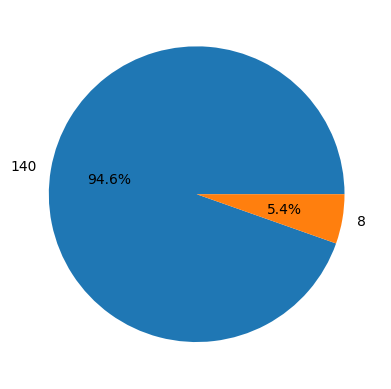

In [ ]:
book_table_Check = dataframe['book_table'].value_counts()

#  Plot the pie chart
plt.pie(book_table_Check, labels=book_table_Check, autopct='%1.1f%%')

plt.show()

# Conclusion : 5.4% people do book a table.

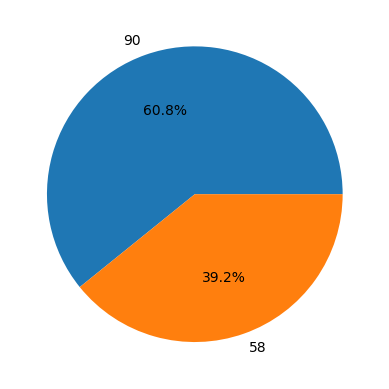

In [ ]:
online_order_Check = dataframe['online_order'].value_counts()

#  Plot the pie chart
plt.pie(online_order_Check, labels=online_order_Check, autopct='%1.1f%%')

plt.show()

# Conclusion : 60.8% of people place online orders.

Text(0.5, 0, 'Type of restaurant')

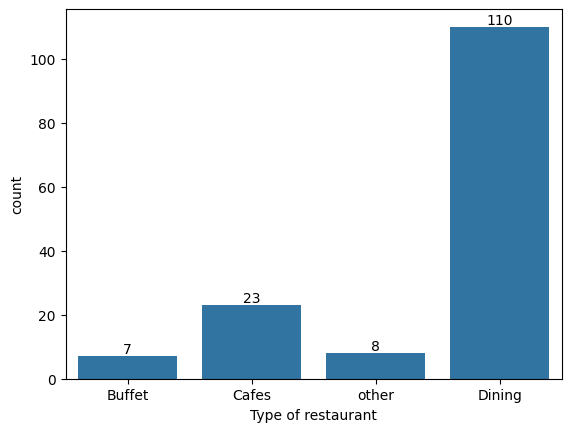

In [ ]:
# check the listed_in (type) column.
ax=sns.countplot(x='listed_in(type)',data=dataframe)

ax.bar_label(ax.containers[0])

plt.xlabel("Type of restaurant")

# Conclusion: The majority of the restaurants fall into the dining category.

Text(0, 0.5, 'Votes')

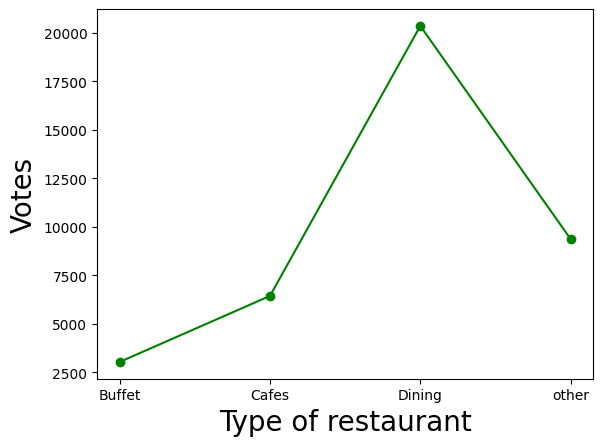

In [ ]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()

result = pd.DataFrame({'votes': grouped_data})

plt.plot(result, c='green', marker='o')

plt.xlabel('Type of restaurant',size=20)

plt.ylabel('Votes',size=20)





# Conclusion: Dining restaurants are preferred by a larger number of individuals.

[Text(0, 0, '58'), Text(0, 0, '90')]

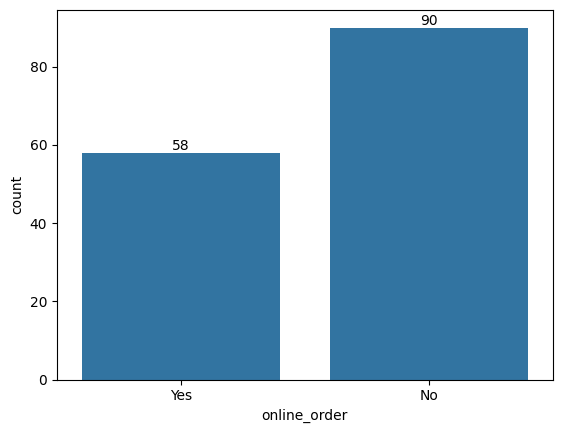

In [ ]:
# Let’s explore the online_order column.

ax=sns.countplot(x='online_order',data=dataframe)

ax.bar_label(ax.containers[0])

# Conclusion: This suggests that a majority of the restaurants do not accept online orders.

In [ ]:
 # we will determine the restaurant’s name that received the maximum votes
 # based on a given data.

max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


# Conclusion : Restaurant 'Empire' has gained maximum votes

In [9]:
# Lets find out the average cost.
dataframe['approx_cost(for two people)'].mean()

np.float64(418.2432432432432)

# Conclusion : Average cost is Rs 418.24

[Text(0, 0, '6'),
 Text(0, 0, '16'),
 Text(0, 0, '16'),
 Text(0, 0, '6'),
 Text(0, 0, '23'),
 Text(0, 0, '3'),
 Text(0, 0, '15'),
 Text(0, 0, '6'),
 Text(0, 0, '14'),
 Text(0, 0, '3'),
 Text(0, 0, '13'),
 Text(0, 0, '2'),
 Text(0, 0, '5'),
 Text(0, 0, '3'),
 Text(0, 0, '12'),
 Text(0, 0, '2'),
 Text(0, 0, '2'),
 Text(0, 0, '1')]

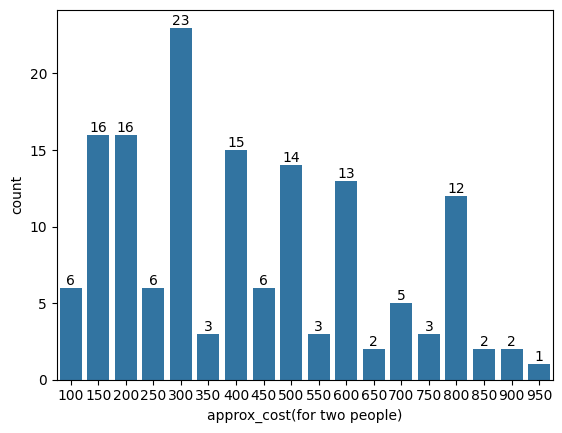

In [ ]:
# explore the approx_cost(for two people) column.

couple_data=dataframe['approx_cost(for two people)']
ax=sns.countplot(x=couple_data)

ax.bar_label(ax.containers[0])

# Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees.

<Axes: xlabel='online_order', ylabel='rate'>

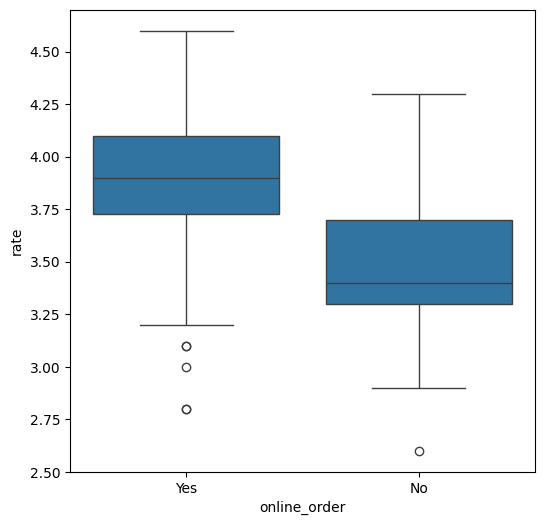

In [ ]:
# we will examine whether online orders receive higher ratings than offline orders.

plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)

# CONCLUSION: Offline orders received lower ratings in comparison to online orders, which obtained excellent ratings.

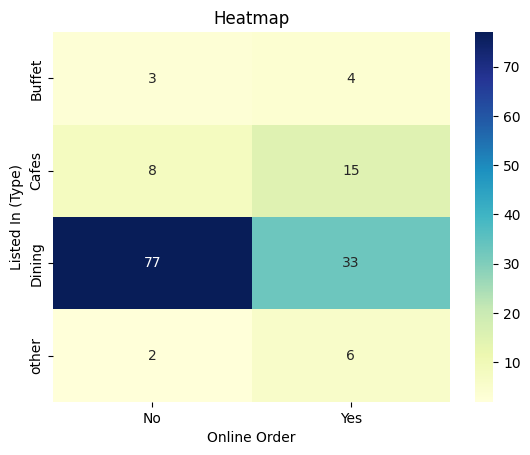

In [ ]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

# CONCLUSION: Dining restaurants primarily accept offline orders, whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants, but prefer online ordering at cafes.